# E0A -- Selección del candidato (Hur vs. Wei vs. Gong, sin ruido)

**Objetivo**: comparar los tres QCNN de literatura (Hur, Wei, Gong) bajo el
mismo protocolo de entrenamiento sobre los tres datasets del rediseño de
Semana 2 (2026-08-24) -- Fashion-MNIST coat vs. shirt, MNIST 4 vs. 9, MNIST
1 vs. 0 -- para decidir cuál avanza a E1/E2. Cong queda fuera de E0A: es la
QCNN genérica de referencia de E0B (validez de la aportación de Hur/Wei/Gong
frente a una QCNN sin sesgo de diseño), no un candidato a "mejor".

**Los dos datasets del diseño original (14-ago-2026: MNIST 1 vs 8,
Fashion-MNIST camiseta-vs-pantalón) quedan obsoletos para E0A** -- ver la
nota de obsolescencia en `00_reproduce_hur.ipynb` y `00_reproduce_wei.ipynb`,
donde esas corridas se conservan solo como referencia histórica de fidelidad
contra los papers originales.

**Criterio de selección (confirmado 2026-08-24, aplicación directa del
protocolo estadístico de `context/diseño_experimentos (2).pdf`)**: media ±
IC bootstrap BCa **por dataset** -- no una cifra resumen única -- con test
pareado de permutación de signo entre modelos y corrección de Holm para el
error de tipo I en las comparaciones múltiples. La configuración completa
(datasets, modelos, protocolo, semillas, criterio estadístico) es un objeto
`ExperimentConfig` inmutable con hash canónico -- ver `configs/e0a.yaml` y
`src/qcnn_benchmark/config/`.

**Aviso de costo de cómputo**: la matriz completa es 3 datasets × 3 modelos
× 5 semillas × 200 actualizaciones = 45 corridas de entrenamiento sobre
simulador cuántico analítico. En el hardware donde se desarrolló este
notebook, cada corrida de Hur/Gong (8 qubits) tomó ~5 min y cada corrida de
Wei (10 qubits) ~2.5 min -- **la matriz completa toma varias horas**. Este
notebook se entrega **sin ejecutar** (como el resto de `00_reproduce_*`);
correrlo es responsabilidad de quien lo ejecute. Hay un interruptor
`FAST_SMOKE_TEST` en la Sec. 1 para validar que el pipeline corre de punta a
punta con un presupuesto reducido antes de comprometerse a la corrida
completa.


In [2]:
import json
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qcnn_benchmark.config import load_config
from qcnn_benchmark.data import load_mnist_pool, load_fashion_mnist_pool
from qcnn_benchmark.representations import build_pca_dataset, build_amplitude_dataset
from qcnn_benchmark.models import qcnn_hur, qcnn_wei, qcnn_gong
from qcnn_benchmark.training import train_binary_classifier, uniform_pi_init, normal_init
from qcnn_benchmark.metrics import batch_accuracy
from qcnn_benchmark.stats import (
    bootstrap_bca_ci,
    paired_sign_permutation_test,
    holm_correction,
    cohens_dz,
    probability_of_superiority,
)


## 1. Configuración declarativa

Se carga `configs/e0a.yaml` (buscado relativo a `notebooks/` o a la raíz del
repo, según desde dónde se lance Jupyter) y se valida contra
`qcnn_benchmark.config.ExperimentConfig` -- cualquier campo faltante o mal
tipado falla aquí, no a medio experimento. `config.canonical_hash()`
identifica esta configuración exacta de forma reproducible entre máquinas;
se usa para nombrar los archivos de resultados y provenance al final.

`FAST_SMOKE_TEST = True` reduce el protocolo a 2 semillas (el mínimo que
`scipy.stats.bootstrap` acepta por muestra) y pocas actualizaciones -- útil para validar que el pipeline corre de punta a punta
sin esperar horas, pero **sus números no son el resultado de E0A**, solo una
prueba de plomería.


In [3]:
FAST_SMOKE_TEST = False  # True = 2 semillas, pocas actualizaciones, solo para validar el pipeline

_CONFIG_CANDIDATES = [pathlib.Path("configs/e0a.yaml"), pathlib.Path("../configs/e0a.yaml")]
CONFIG_PATH = next(p for p in _CONFIG_CANDIDATES if p.exists())
config = load_config(CONFIG_PATH)

if FAST_SMOKE_TEST:
    config = config.model_copy(update={
        "n_seeds": 2,  # 2 es el mínimo que scipy.stats.bootstrap acepta por muestra
        "protocol": config.protocol.model_copy(update={"n_updates": 10, "val_check_every": 5, "patience_checks": 2}),
    })

print("experiment_id:", config.experiment_id)
print("canonical_hash:", config.canonical_hash(), "(FAST_SMOKE_TEST)" if FAST_SMOKE_TEST else "")
print("datasets:", [d.name for d in config.datasets])
print("models:", config.models)
print("run_seeds:", config.run_seeds())
print("protocol:", config.protocol)
print("statistical_criterion:", config.statistical_criterion)


experiment_id: E0A
canonical_hash: 5a6b6cb49509 
datasets: ['coat_vs_shirt', '4_vs_9', '1_vs_0']
models: ['hur', 'wei', 'gong']
run_seeds: [0, 1, 2, 3, 4]
protocol: batch_size=25 n_updates=500 learning_rate=0.01 beta1=0.9 beta2=0.999 clip_norm=5.0 val_check_every=10 patience_checks=5 min_delta=0.0001
statistical_criterion: aggregation='mean_per_dataset' ci_method='bootstrap_bca' n_bootstrap=10000 confidence_level=0.95 comparison_test='paired_sign_permutation' multiple_comparison_correction='holm' alpha=0.05


## 2. Registro de modelos y representaciones

Cada modelo trae su propia representación (misma que en su
`00_reproduce_*.ipynb` de fidelidad): PCA-16 para Hur, amplitud (1024) para
Wei, PCA-8 para Gong (rellenada internamente a la capacidad del encoding
tree-hybrid, ver `qcnn_gong.py`). Los pools crudos de MNIST/Fashion-MNIST se
cachean por `(source, normalize)` para no releerlos/re-normalizarlos una vez
por combinación dataset×modelo.


In [4]:
MODEL_REGISTRY = {
    "hur": {"module": qcnn_hur, "init": uniform_pi_init, "normalize": True,
            "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=16, verbose=False)},
    "wei": {"module": qcnn_wei, "init": normal_init, "normalize": False,
            "build_rep": lambda x, y, pos, neg: build_amplitude_dataset(x, y, pos, neg, verbose=False)},
    "gong": {"module": qcnn_gong, "init": uniform_pi_init, "normalize": True,
             "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=8, verbose=False)},
}

_POOL_CACHE = {}


def get_pool(source, normalize):
    key = (source, normalize)
    if key not in _POOL_CACHE:
        loader = load_mnist_pool if source == "mnist" else load_fashion_mnist_pool
        _POOL_CACHE[key] = loader(normalize=normalize)
    return _POOL_CACHE[key]


## 3. Ejecución (matriz completa: datasets × modelos × semillas)

Mismo protocolo (`qcnn_benchmark.training.train_binary_classifier`) para los
tres modelos, tomado de `config.protocol`. Los resultados crudos (una fila
por corrida dataset×modelo×semilla) se guardan en
`results/e0a_raw_<hash>.csv` conforme se producen, para no perder progreso
si la corrida completa se interrumpe.


In [5]:
RESULTS_DIR = pathlib.Path("results") if pathlib.Path("results").exists() else pathlib.Path("../results")
raw_path = RESULTS_DIR / f"e0a_raw_{config.canonical_hash()}.csv"

rows = []
t_start = time.time()
for dataset in config.datasets:
    for model_name in config.models:
        entry = MODEL_REGISTRY[model_name]
        x_all, y_all = get_pool(dataset.source, entry["normalize"])
        rep = entry["build_rep"](x_all, y_all, dataset.class_pos, dataset.class_neg)

        for seed in config.run_seeds():
            tag = f"{dataset.name}-{model_name}-seed{seed}"
            result = train_binary_classifier(
                entry["module"].predict_proba, entry["module"].TOTAL_PARAMS, rep, entry["init"],
                run_seed=seed,
                batch_size=config.protocol.batch_size,
                n_updates=config.protocol.n_updates,
                learning_rate=config.protocol.learning_rate,
                beta1=config.protocol.beta1,
                beta2=config.protocol.beta2,
                clip_norm=config.protocol.clip_norm,
                val_check_every=config.protocol.val_check_every,
                patience_checks=config.protocol.patience_checks,
                min_delta=config.protocol.min_delta,
                verbose=False,
                tag=tag,
            )
            train_acc = batch_accuracy(entry["module"].predict_proba, result["params"], rep["X_train"], rep["y_train"])
            test_acc = batch_accuracy(entry["module"].predict_proba, result["params"], rep["X_test"], rep["y_test"])
            rows.append({
                "dataset": dataset.name, "model": model_name, "seed": seed,
                "train_acc": train_acc, "test_acc": test_acc,
                "n_updates_run": result["n_updates_run"], "stopped_early_at": result["stopped_early_at"],
                "best_val_loss": result["best_val_loss"],
            })
            print(f"[{tag}] test_acc={test_acc:.4f}  (t={time.time()-t_start:.0f}s acumulado)")

            raw_df = pd.DataFrame(rows)
            raw_df.to_csv(raw_path, index=False)  # checkpoint incremental

print("Total:", time.time() - t_start, "s")
raw_df = pd.DataFrame(rows)
raw_df


[coat_vs_shirt-hur-seed0] test_acc=0.7600  (t=4621s acumulado)
[coat_vs_shirt-hur-seed1] test_acc=0.7470  (t=7440s acumulado)
[coat_vs_shirt-hur-seed2] test_acc=0.7160  (t=10139s acumulado)
[coat_vs_shirt-hur-seed3] test_acc=0.7150  (t=14741s acumulado)
[coat_vs_shirt-hur-seed4] test_acc=0.7360  (t=17160s acumulado)
[coat_vs_shirt-wei-seed0] test_acc=0.7720  (t=18799s acumulado)
[coat_vs_shirt-wei-seed1] test_acc=0.7750  (t=20457s acumulado)
[coat_vs_shirt-wei-seed2] test_acc=0.7700  (t=21955s acumulado)
[coat_vs_shirt-wei-seed3] test_acc=0.7740  (t=23609s acumulado)
[coat_vs_shirt-wei-seed4] test_acc=0.7640  (t=25256s acumulado)
[coat_vs_shirt-gong-seed0] test_acc=0.7480  (t=27290s acumulado)
[coat_vs_shirt-gong-seed1] test_acc=0.7480  (t=29275s acumulado)
[coat_vs_shirt-gong-seed2] test_acc=0.7340  (t=31192s acumulado)
[coat_vs_shirt-gong-seed3] test_acc=0.7310  (t=33270s acumulado)
[coat_vs_shirt-gong-seed4] test_acc=0.7440  (t=36137s acumulado)
[4_vs_9-hur-seed0] test_acc=0.8120  (

,dataset,model,seed,train_acc,test_acc,n_updates_run,stopped_early_at,best_val_loss
0,coat_vs_shirt,hur,0,0.742,0.760,490,490.0,0.599380
1,coat_vs_shirt,hur,1,0.725,0.747,300,300.0,0.574799
2,coat_vs_shirt,hur,2,0.719,0.716,280,280.0,0.607881
3,coat_vs_shirt,hur,3,0.720,0.715,500,NaN,0.593629
4,coat_vs_shirt,hur,4,0.742,0.736,260,260.0,0.568457
5,coat_vs_shirt,wei,0,0.747,0.772,500,NaN,0.526474
6,coat_vs_shirt,wei,1,0.782,0.775,500,NaN,0.516676
7,coat_vs_shirt,wei,2,0.744,0.770,450,450.0,0.533624
8,coat_vs_shirt,wei,3,0.774,0.774,500,NaN,0.514200
9,coat_vs_shirt,wei,4,0.771,0.764,500,NaN,0.482949


## 4. Resultados crudos

Una fila por corrida (dataset × modelo × semilla). Guardados en
`results/e0a_raw_<hash>.csv` conforme se produjeron (celda anterior).


In [6]:
raw_df = pd.read_csv(raw_path)
display(raw_df)
raw_df.pivot_table(index="dataset", columns="model", values="test_acc", aggfunc=list)


,dataset,model,seed,train_acc,test_acc,n_updates_run,stopped_early_at,best_val_loss
0,coat_vs_shirt,hur,0,0.742,0.760,490,490.0,0.599380
1,coat_vs_shirt,hur,1,0.725,0.747,300,300.0,0.574799
2,coat_vs_shirt,hur,2,0.719,0.716,280,280.0,0.607881
3,coat_vs_shirt,hur,3,0.720,0.715,500,NaN,0.593629
4,coat_vs_shirt,hur,4,0.742,0.736,260,260.0,0.568457
5,coat_vs_shirt,wei,0,0.747,0.772,500,NaN,0.526474
6,coat_vs_shirt,wei,1,0.782,0.775,500,NaN,0.516676
7,coat_vs_shirt,wei,2,0.744,0.770,450,450.0,0.533624
8,coat_vs_shirt,wei,3,0.774,0.774,500,NaN,0.514200
9,coat_vs_shirt,wei,4,0.771,0.764,500,NaN,0.482949


model,gong,hur,wei
dataset,,,
1_vs_0,"[0.987, 0.986, 0.989, 0.988, 0.987]","[0.984, 0.989, 0.988, 0.993, 0.992]","[0.995, 0.993, 0.988, 0.994, 0.992]"
4_vs_9,"[0.776, 0.832, 0.776, 0.836, 0.826]","[0.812, 0.834, 0.847, 0.834, 0.847]","[0.958, 0.959, 0.944, 0.955, 0.953]"
coat_vs_shirt,"[0.748, 0.748, 0.734, 0.731, 0.744]","[0.76, 0.747, 0.716, 0.715, 0.736]","[0.772, 0.775, 0.77, 0.774, 0.764]"


## 5. Métricas agregadas (media ± IC bootstrap BCa por dataset)

Por construcción del criterio confirmado: **una media ± IC por (dataset,
modelo)**, no un promedio único entre datasets que oculte en qué dataset
gana cada modelo.


In [7]:
agg_rows = []
for (dataset_name, model_name), group in raw_df.groupby(["dataset", "model"]):
    accs = group["test_acc"].to_numpy()
    lo, hi = bootstrap_bca_ci(
        accs, n_bootstrap=config.statistical_criterion.n_bootstrap,
        confidence_level=config.statistical_criterion.confidence_level,
        rng=np.random.default_rng(0),
    )
    agg_rows.append({
        "dataset": dataset_name, "model": model_name,
        "mean_test_acc": float(np.mean(accs)), "ci_lo": lo, "ci_hi": hi, "n_seeds": len(accs),
    })

agg_df = pd.DataFrame(agg_rows)
agg_df


,dataset,model,mean_test_acc,ci_lo,ci_hi,n_seeds
0,1_vs_0,gong,0.9874,0.9864,0.9882,5
1,1_vs_0,hur,0.9892,0.9858,0.9918,5
2,1_vs_0,wei,0.9924,0.9896,0.9940,5
3,4_vs_9,gong,0.8092,0.7860,0.8320,5
4,4_vs_9,hur,0.8348,0.8190,0.8418,5
5,4_vs_9,wei,0.9538,0.9476,0.9574,5
6,coat_vs_shirt,gong,0.7410,0.7342,0.7472,5
7,coat_vs_shirt,hur,0.7348,0.7198,0.7510,5
8,coat_vs_shirt,wei,0.7710,0.7668,0.7736,5


## 6. Análisis estadístico (permutación pareada + Holm, tamaños de efecto)

Comparaciones pareadas por semilla (misma semilla = mismo `run_seed`, mismo
punto de partida de inicialización dentro de cada modelo) entre cada par de
modelos, dentro de cada dataset. La corrección de Holm se aplica **sobre la
familia completa de las 9 comparaciones** (3 datasets × 3 pares de modelos)
-- la elección más conservadora quando el diseño no especifica si las
familias son por dataset o globales; ajustar `groupby` más abajo si se
prefiere corregir por dataset en vez de globalmente.


In [8]:
from itertools import combinations

comparison_rows = []
for dataset_name, group in raw_df.groupby("dataset"):
    pivot = group.pivot(index="seed", columns="model", values="test_acc")
    for model_a, model_b in combinations(config.models, 2):
        x, y = pivot[model_a].to_numpy(), pivot[model_b].to_numpy()
        p_value, mean_diff = paired_sign_permutation_test(
            x, y, n_permutations=config.statistical_criterion.n_bootstrap,
            rng=np.random.default_rng(0),
        )
        comparison_rows.append({
            "dataset": dataset_name, "model_a": model_a, "model_b": model_b,
            "mean_diff_a_minus_b": mean_diff, "p_value": p_value,
            "cohens_dz": cohens_dz(x, y), "prob_superiority_a_over_b": probability_of_superiority(x, y),
        })

comparisons_df = pd.DataFrame(comparison_rows)
adjusted, rejected = holm_correction(comparisons_df["p_value"], alpha=config.statistical_criterion.alpha)
comparisons_df["p_value_holm"] = adjusted
comparisons_df["significant"] = rejected
comparisons_df


,dataset,model_a,model_b,mean_diff_a_minus_b,p_value,cohens_dz,prob_superiority_a_over_b,p_value_holm,significant
0,1_vs_0,hur,wei,-0.0032,0.2500,-0.686942,0.2,0.7500,False
1,1_vs_0,hur,gong,0.0018,0.3750,0.495434,0.6,0.7500,False
2,1_vs_0,wei,gong,0.0050,0.1250,1.414214,0.8,0.6250,False
3,4_vs_9,hur,wei,-0.1190,0.0625,-6.311421,0.0,0.5625,False
4,4_vs_9,hur,gong,0.0256,0.1875,0.864303,0.8,0.7500,False
5,4_vs_9,wei,gong,0.1446,0.0625,5.095531,1.0,0.5625,False
6,coat_vs_shirt,hur,wei,-0.0362,0.0625,-1.834941,0.0,0.5625,False
7,coat_vs_shirt,hur,gong,-0.0062,0.3125,-0.507583,0.2,0.7500,False
8,coat_vs_shirt,wei,gong,0.0300,0.0625,3.207135,1.0,0.5625,False


## 7. Figuras y tablas


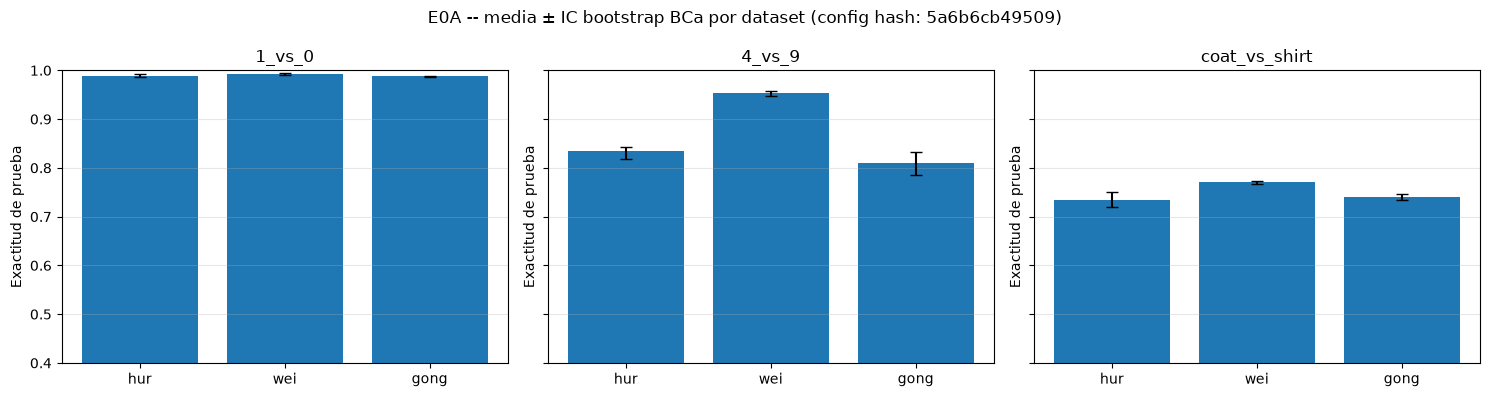

In [9]:
fig, axes = plt.subplots(1, len(config.datasets), figsize=(5 * len(config.datasets), 4), sharey=True)
for ax, (dataset_name, group) in zip(axes, agg_df.groupby("dataset")):
    group = group.set_index("model").loc[config.models]
    yerr = [group["mean_test_acc"] - group["ci_lo"], group["ci_hi"] - group["mean_test_acc"]]
    ax.bar(group.index, group["mean_test_acc"], yerr=yerr, capsize=4)
    ax.set_title(dataset_name)
    ax.set_ylabel("Exactitud de prueba")
    ax.set_ylim(0.4, 1.0)
    ax.grid(alpha=0.3, axis="y")
plt.suptitle("E0A -- media ± IC bootstrap BCa por dataset (config hash: " + config.canonical_hash() + ")")
plt.tight_layout()
plt.show()


In [10]:
display(comparisons_df.style.format({
    "mean_diff_a_minus_b": "{:+.4f}", "p_value": "{:.4f}", "p_value_holm": "{:.4f}",
    "cohens_dz": "{:.2f}", "prob_superiority_a_over_b": "{:.2f}",
}))


,dataset,model_a,model_b,mean_diff_a_minus_b,p_value,cohens_dz,prob_superiority_a_over_b,p_value_holm,significant
0,1_vs_0,hur,wei,-0.0032,0.2500,-0.69,0.20,0.7500,False
1,1_vs_0,hur,gong,+0.0018,0.3750,0.50,0.60,0.7500,False
2,1_vs_0,wei,gong,+0.0050,0.1250,1.41,0.80,0.6250,False
3,4_vs_9,hur,wei,-0.1190,0.0625,-6.31,0.00,0.5625,False
4,4_vs_9,hur,gong,+0.0256,0.1875,0.86,0.80,0.7500,False
5,4_vs_9,wei,gong,+0.1446,0.0625,5.10,1.00,0.5625,False
6,coat_vs_shirt,hur,wei,-0.0362,0.0625,-1.83,0.00,0.5625,False
7,coat_vs_shirt,hur,gong,-0.0062,0.3125,-0.51,0.20,0.7500,False
8,coat_vs_shirt,wei,gong,+0.0300,0.0625,3.21,1.00,0.5625,False


## 8. Selección del candidato

Por dataset: el modelo con mayor media gana ese dataset; se marca como
**significativamente** mejor solo si el test pareado contra el segundo lugar
sigue siendo significativo tras Holm (`p_value_holm < alpha`). No se calcula
un ranking global de una sola cifra -- ese fue precisamente el criterio
confirmado (media ± IC **por dataset**, no un promedio entre datasets).


In [11]:
alpha = config.statistical_criterion.alpha
print(f"Criterio: mejor media por dataset, marcada 'significativo' solo si supera al segundo lugar con p_holm < {alpha}\n")

for dataset_name, group in agg_df.groupby("dataset"):
    ranked = group.sort_values("mean_test_acc", ascending=False).reset_index(drop=True)
    winner, runner_up = ranked.loc[0, "model"], ranked.loc[1, "model"]
    row = comparisons_df[
        (comparisons_df["dataset"] == dataset_name)
        & (comparisons_df[["model_a", "model_b"]].isin([winner, runner_up]).all(axis=1))
    ]
    is_significant = bool(row["significant"].iloc[0]) if len(row) else None
    print(f"{dataset_name}: gana {winner} ({ranked.loc[0, 'mean_test_acc']:.4f}) "
          f"sobre {runner_up} ({ranked.loc[1, 'mean_test_acc']:.4f}) "
          f"-- {'significativo' if is_significant else 'NO significativo'} tras Holm")


Criterio: mejor media por dataset, marcada 'significativo' solo si supera al segundo lugar con p_holm < 0.05

1_vs_0: gana wei (0.9924) sobre hur (0.9892) -- NO significativo tras Holm
4_vs_9: gana wei (0.9538) sobre hur (0.8348) -- NO significativo tras Holm
coat_vs_shirt: gana wei (0.7710) sobre gong (0.7410) -- NO significativo tras Holm


## 9. Registro de reproducibilidad


In [12]:
import pennylane, sklearn, scipy

provenance = {
    "experiment_id": config.experiment_id,
    "canonical_hash": config.canonical_hash(),
    "config": json.loads(config.canonical_json()),
    "fast_smoke_test": FAST_SMOKE_TEST,
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "raw_results_path": str(raw_path),
    "package_versions": {
        "pennylane": pennylane.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
    },
}

provenance_path = RESULTS_DIR / f"e0a_provenance_{config.canonical_hash()}.json"
provenance_path.write_text(json.dumps(provenance, indent=2, ensure_ascii=False))
print("Provenance guardado en:", provenance_path)
print(json.dumps(provenance, indent=2, ensure_ascii=False))


Provenance guardado en: ../results/e0a_provenance_5a6b6cb49509.json
{
  "experiment_id": "E0A",
  "canonical_hash": "5a6b6cb49509",
  "config": {
    "datasets": [
      {
        "class_neg": 6,
        "class_pos": 4,
        "name": "coat_vs_shirt",
        "source": "fashion_mnist"
      },
      {
        "class_neg": 9,
        "class_pos": 4,
        "name": "4_vs_9",
        "source": "mnist"
      },
      {
        "class_neg": 0,
        "class_pos": 1,
        "name": "1_vs_0",
        "source": "mnist"
      }
    ],
    "description": "Comparación Hur vs. Wei vs. Gong (E0, sin ruido, simulador analítico) sobre los tres datasets del rediseño de Semana 2, para seleccionar el candidato que avanza a E1/E2. Cong queda fuera de E0A -- es la QCNN genérica de referencia de E0B (validez de la aportación), no un candidato a \"mejor\".\n",
    "experiment_id": "E0A",
    "models": [
      "hur",
      "wei",
      "gong"
    ],
    "n_seeds": 5,
    "protocol": {
      "batch_size":

/tmp/ipykernel_2871427/1414723639.py:8: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
